# Test to get this 'Csordas' subnetwork method working

# WITH NORMALIZATION, NO SCALING [0, 1], Train and Test set used

In [ ]:
import torch
import torchvision
import framework
import tasks
import os

# Fake-run the test command to populate 'sys.argv'

import shlex
import sys

# base_path = "./save/cifar10_Tr50k_Te10K_split_one_mask_per_class_test_2"
base_path = "./save/cifar10_Tr50k_Te10K_split_one_mask_per_class_Model-5_Mask-1"
MODEL_ID = 5
MASK_ID = 3

# Note: The commands are switch depending on if a training has already occurred, and you only wish to test a pretrained model and masks.
cmd = f"main.py -name cifar10_Tr50k_Te10K_split_one_mask_per_class_Model-{MODEL_ID}_Mask-{MASK_ID} -task cifar10_class_removal -stop_after 20000 -mask_loss_weight 3e-4 -mask_lr 1e-3 -step_per_mask 20000 -class_removal.keep_last_layer 1 -dropout 0.0 -cnn.dropout 0 -restore_pretrained {base_path}/model_weights"

# cmd = "main.py -name cifar10_Tr50k_Te10K_split_one_mask_per_class_test_2 -task cifar10_class_removal -stop_after 20000 -mask_loss_weight 3e-4 -mask_lr 1e-3 -step_per_mask 20000 -class_removal.keep_last_layer 1 -dropout 0.0 -cnn.dropout 0"
cmd_args = shlex.split(cmd)
sys.argv = cmd_args

print(cmd_args)

['main.py', '-name', 'cifar10_Tr50k_Te10K_split_one_mask_per_class_Model-4_Mask-5', '-task', 'cifar10_class_removal', '-stop_after', '20000', '-mask_loss_weight', '3e-4', '-mask_lr', '1e-3', '-step_per_mask', '20000', '-class_removal.keep_last_layer', '1', '-dropout', '0.0', '-cnn.dropout', '0', '-restore_pretrained', './save/cifar10_Tr50k_Te10K_split_one_mask_per_class_Model-4_Mask-1/model_weights']


In [2]:
from main import register_args, load_weights, save_weights

training_helper = framework.helpers.TrainingHelper(
    wandb_project_name="modules",
    register_args=register_args, 
    extra_dirs=["export", "model_weights"])

def invalid_task_error(self):
    assert False, f"Invalid task: {training_helper.opt.task}"

constructors = {
    "tuple": tasks.TupleTask,
    "tuple_ff": tasks.TupleTaskFeedforward,
    "scan": tasks.ScanTask,
    "trafo_scan": tasks.TransformerScanTask,
    "addmul_ff": tasks.AddMulFeedforward,
    "addmul": tasks.AddMulTask,
    "cifar10_class_removal": tasks.Cifar10ClassRemovalTask,
    "cifar10_resnet_hp_class_removal": tasks.Cifar10ResnetHPClassRemovalTask,
    "cifar10_mask_stability": tasks.Cifar10MaskStabilityTask,
    "cifar10_grad_cos_distance": tasks.Cifar10GradCosDistanceTask,
    "permuted_mnist": tasks.PermutedMnistTask,
    "deepmind_math": tasks.DeepmindMathTask,
    "tuple_ff_copyweight": tasks.TupleFeedforwardCopyweightTask
}

task = constructors.get(training_helper.opt.task, invalid_task_error)(training_helper)

#########################
DROPOUT:
False
#########################
Found module parameters: ['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight']
Masking is applied to paramteres: {'features_3_weight', 'features_6_weight', 'features_3_bias', 'features_10_weight', 'features_0_weight', 'out_layer_weight', 'features_6_bias', 'features_0_bias', 'out_layer_bias', 'features_10_bias'}
Masking 390986 out of 390986 parameters (100.0 %)


/home/gulmar/miniconda3/envs/test_csordas/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


In [3]:
if training_helper.opt.restore_pretrained:
    assert not task.helper.opt.train_baseline
    load_weights(training_helper, task)
    if training_helper.opt.test_pretrained:
        training_helper.summary.log({f"load_validation/{k}": v for k, v in task.validate().items()})
    print("Done. Skipping training...")
else:
    if task.helper.opt.train_baseline:
        task.set_baseline_mode()

    task.train()

    print("Training finished. Saving model...")
    save_weights(training_helper, task)

Loading pretrained weights from ./save/cifar10_Tr50k_Te10K_split_one_mask_per_class_Model-4_Mask-1/model_weights/model.pth...


/home/gulmar/Library/Projects/Csordas_modules/main.py:169: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(pretrained)


Done. Skipping training...


In [4]:
if task.helper.opt.analysis.enable and not task.helper.opt.train_baseline:
    task.post_train_2()

stage / mask_id: 0 / -1
Set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ----> Mask class: -1


/home/gulmar/miniconda3/envs/test_csordas/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Now mask step: 0 (iter: 0, start: 0)
Now mask step: 2000 (iter: 2000, start: 0)
Now mask step: 4000 (iter: 4000, start: 0)
Now mask step: 6000 (iter: 6000, start: 0)
Now mask step: 8000 (iter: 8000, start: 0)
Now mask step: 10000 (iter: 10000, start: 0)
Now mask step: 12000 (iter: 12000, start: 0)
Now mask step: 14000 (iter: 14000, start: 0)
Now mask step: 16000 (iter: 16000, start: 0)
Now mask step: 18000 (iter: 18000, start: 0)
Now mask step: 20000 (iter: 20000, start: 0)
Half-mask test, stage: control, iteration 0: keeping masks for the following layers (6 out of 10): {'features_3_weight', 'features_6_weight', 'features_3_bias', 'features_0_weight', 'features_6_bias', 'features_0_bias'}
Inverse: masking 4 out of 10: {'features_10_weight', 'out_layer_bias', 'features_10_bias', 'out_layer_weight'}
stage / mask_id: 1 / 0
Optimizing:  ['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_

/home/gulmar/miniconda3/envs/test_csordas/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Now mask step: 1999 (iter: 22000, start: 20001)
Now mask step: 3999 (iter: 24000, start: 20001)
Now mask step: 5999 (iter: 26000, start: 20001)
Now mask step: 7999 (iter: 28000, start: 20001)
Now mask step: 9999 (iter: 30000, start: 20001)
Now mask step: 11999 (iter: 32000, start: 20001)
Now mask step: 13999 (iter: 34000, start: 20001)
Now mask step: 15999 (iter: 36000, start: 20001)
Now mask step: 17999 (iter: 38000, start: 20001)
Now mask step: 19999 (iter: 40000, start: 20001)
stage / mask_id: 2 / 1
Optimizing:  ['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight']
Set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ----> Mask class: 1


...

Now mask step: 1992 (iter: 162000, start: 160008)
Now mask step: 3992 (iter: 164000, start: 160008)
Now mask step: 5992 (iter: 166000, start: 160008)
Now mask step: 7992 (iter: 168000, start: 160008)
Now mask step: 9992 (iter: 170000, start: 160008)
Now mask step: 11992 (iter: 172000, start: 160008)
Now mask step: 13992 (iter: 174000, start: 160008)
Now mask step: 15992 (iter: 176000, start: 160008)
Now mask step: 17992 (iter: 178000, start: 160008)
Now mask step: 19992 (iter: 180000, start: 160008)
stage / mask_id: 9 / 8
Optimizing:  ['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight']
Set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ----> Mask class: 8


/home/gulmar/miniconda3/envs/test_csordas/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Now mask step: 1991 (iter: 182000, start: 180009)
Now mask step: 3991 (iter: 184000, start: 180009)
Now mask step: 5991 (iter: 186000, start: 180009)
Now mask step: 7991 (iter: 188000, start: 180009)
Now mask step: 9991 (iter: 190000, start: 180009)
Now mask step: 11991 (iter: 192000, start: 180009)
Now mask step: 13991 (iter: 194000, start: 180009)
Now mask step: 15991 (iter: 196000, start: 180009)
Now mask step: 17991 (iter: 198000, start: 180009)
Now mask step: 19991 (iter: 200000, start: 180009)
stage / mask_id: 10 / 9
Optimizing:  ['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight']
Set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ----> Mask class: 9


/home/gulmar/miniconda3/envs/test_csordas/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Now mask step: 1990 (iter: 202000, start: 200010)
Now mask step: 3990 (iter: 204000, start: 200010)
Now mask step: 5990 (iter: 206000, start: 200010)
Now mask step: 7990 (iter: 208000, start: 200010)
Now mask step: 9990 (iter: 210000, start: 200010)
Now mask step: 11990 (iter: 212000, start: 200010)
Now mask step: 13990 (iter: 214000, start: 200010)
Now mask step: 15990 (iter: 216000, start: 200010)
Now mask step: 17990 (iter: 218000, start: 200010)
Now mask step: 19990 (iter: 220000, start: 200010)


In [10]:
task.helper.device

device(type='cuda')

In [12]:
from pathlib import Path

final_masks_path = f"{base_path}/export/stage_final_masks/"

def load_masks(task, path):
    path = Path(path)
    for stage_p in path.iterdir():
        stage = int(stage_p.name.split("_")[-1])
        for layer_p in stage_p.iterdir():
            layer_name = layer_p.name.split(".")[0]
            layer_weights = torch.load(layer_p, weights_only=False)
            task.model.masks[stage][layer_name] = task.helper.to_device(torch.tensor(layer_weights))

load_masks(task, final_masks_path)

In [13]:
for i in range(len(task.model.masks)):
    print(f"Mask {i}: {task.model.masks[i].keys()}")

Mask 0: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 1: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 2: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 3: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 4: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 

In [14]:
# step = 10 # Number of "layers" per 'mask-dict'
# loaded_masks = torch.nn.ModuleList([torch.nn.ParameterDict({layer_name: torch.nn.Parameter(mask_params) 
#  for (layer_name, _), (long_layer_name, mask_params) in zip(task.model.model_parameters.items(), list(test["model"].items())[step+i*step:i*step+step+step])
#  if task.mask_filter(layer_name)})
#  for i in range(task.get_n_masks())
#     ])

# task.model.masks = loaded_masks

100%|██████████| 79/79 [00:00<00:00, 230.75it/s]


Validation accuracy on iid: 0.7852


100%|██████████| 79/79 [00:00<00:00, 250.25it/s]


Validation accuracy on train: 0.9937


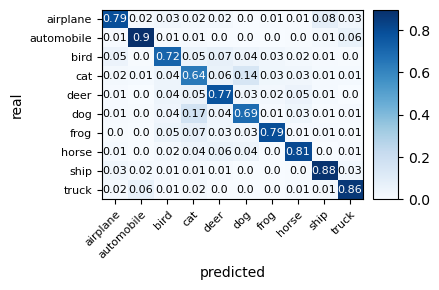

In [15]:
%matplotlib inline

import matplotlib.pyplot as plt

a = {f"validation/{k}": v for k, v in task.validate().items() if k.endswith("/confusion")}

a["validation/iid/confusion"].to_matplotlib()
plt.show()

In [16]:
task.validate().items()

100%|██████████| 79/79 [00:00<00:00, 258.12it/s]


Validation accuracy on iid: 0.7852


100%|██████████| 79/79 [00:00<00:00, 257.80it/s]

Validation accuracy on train: 0.9937


dict_items([('iid/loss', 1.4549114166259767), ('iid/accuracy', 0.7852), ('iid/confusion', <framework.visualize.plot.ConfusionMatrix object at 0x7f7d44783a40>), ('train/loss', 0.0036137535493075846), ('train/accuracy', 0.9937), ('train/confusion', <framework.visualize.plot.ConfusionMatrix object at 0x7f7d44783c80>), ('mean_accuracy', 0.8894500000000001), ('mean_loss', 0.7292625850876421)])

In [17]:
stage = 0
task.model.set_active(stage)
test, b = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid) 

confusion = test.confusion.type(torch.float32)
confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
if stage == 0:
    confusion_ref = confusion

  0%|          | 0/79 [00:00<?, ?it/s]

100%|██████████| 79/79 [00:00<00:00, 242.57it/s]


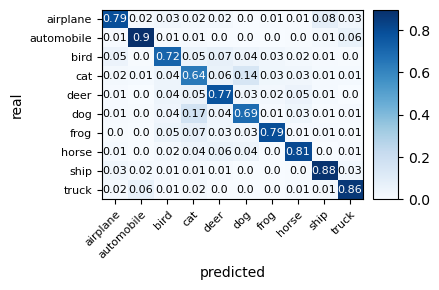

In [18]:
task.draw_confusion_heatmap(confusion_ref).to_matplotlib()
plt.show()

100%|██████████| 79/79 [00:00<00:00, 247.73it/s]


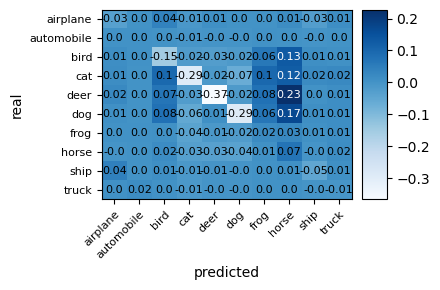

In [19]:
stage = 2
task.model.set_active(stage)
test, b = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
confusion = test.confusion.type(torch.float32)
confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
diff = confusion - confusion_ref

task.draw_confusion_heatmap(diff).to_matplotlib()
plt.show()

In [20]:
model_1 = task.model.masks[0]

# Count total parameters (for comparison)
total_params = sum(p.numel() for p in model_1.parameters() if p.requires_grad)
# Count only nonzero parameters
nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

print(f"Total parameters:           {total_params:,}")
print(f"Nonzero parameters:         {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

Total parameters:           390,986
Nonzero parameters:         198,071 --- 50.66%


In [21]:
task.valid_sets

{'iid': <dataset.image.cifar.CIFAR10 at 0x7f7d448ebd40>,
 'train': <dataset.image.cifar.CIFAR10 at 0x7f7d4497fa40>}

In [22]:
task.prepare_model_for_analysis()

# count = 0
for stage, mask_id in enumerate([-1]+task.mask_classes):
    # if count > 1:
    #     break
    # count += 1
    split = "baseline" if stage==0 else task.train_set.class_names[mask_id]

    task.model.set_active(stage)

    # set = task.create_restricted_train_set([i for i in range(task.train_set.n_classes) if i != mask_id])
    # if mask_id == -1:
    #     include_classes = [i for i in range(task.train_set.n_classes) if i != mask_id]
    # else:
    #     include_classes = [mask_id]

    # set = task.create_restricted_train_set(include_classes)
    # task.create_validate_on_train(set)

    print(f"stage/mask_id: {stage}/{mask_id}")

    model_1 = task.model.masks[stage]
    nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

    print(f"Nonzero parameters:   {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

    # If mask is finished training
    # test, _ = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
    # print(f"Self-class accuracy: {test.accuracy}")

    print("#######################")
        

stage/mask_id: 0/-1
Nonzero parameters:   198,071 --- 50.66%
#######################
stage/mask_id: 1/0
Nonzero parameters:   110,618 --- 28.29%
#######################
stage/mask_id: 2/1
Nonzero parameters:   92,451 --- 23.65%
#######################
stage/mask_id: 3/2
Nonzero parameters:   122,682 --- 31.38%
#######################
stage/mask_id: 4/3
Nonzero parameters:   125,155 --- 32.01%
#######################
stage/mask_id: 5/4
Nonzero parameters:   114,872 --- 29.38%
#######################
stage/mask_id: 6/5
Nonzero parameters:   118,029 --- 30.19%
#######################
stage/mask_id: 7/6
Nonzero parameters:   101,809 --- 26.04%
#######################
stage/mask_id: 8/7
Nonzero parameters:   110,558 --- 28.28%
#######################
stage/mask_id: 9/8
Nonzero parameters:   94,108 --- 24.07%
#######################
stage/mask_id: 10/9
Nonzero parameters:   100,455 --- 25.69%
#######################


In [23]:
len(task.valid_sets.iid)

10000

stage/mask_id: 0/-1
Nonzero parameters:   198,071 --- 50.66%


100%|██████████| 79/79 [00:00<00:00, 229.32it/s]


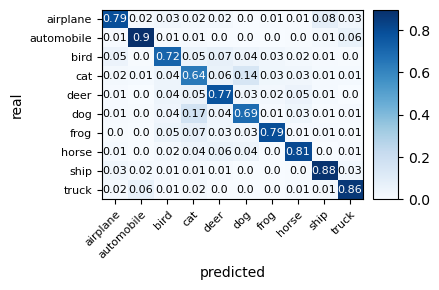

stage/mask_id: 1/0
Nonzero parameters:   110,618 --- 28.29%


100%|██████████| 79/79 [00:00<00:00, 250.90it/s]


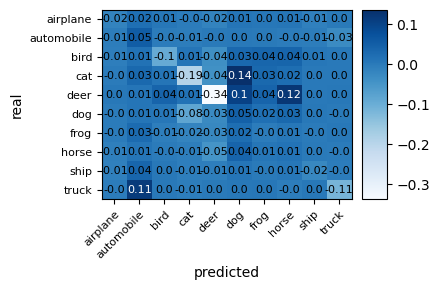

stage/mask_id: 2/1
Nonzero parameters:   92,451 --- 23.65%


100%|██████████| 79/79 [00:00<00:00, 244.42it/s]


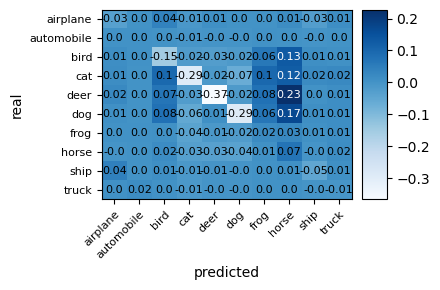

stage/mask_id: 3/2
Nonzero parameters:   122,682 --- 31.38%


100%|██████████| 79/79 [00:00<00:00, 245.92it/s]


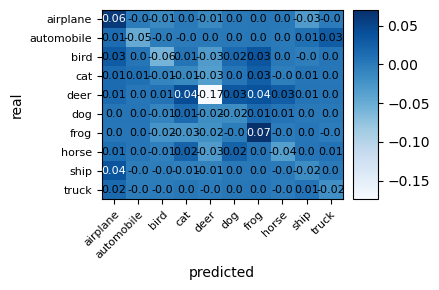

stage/mask_id: 4/3
Nonzero parameters:   125,155 --- 32.01%


100%|██████████| 79/79 [00:00<00:00, 227.91it/s]


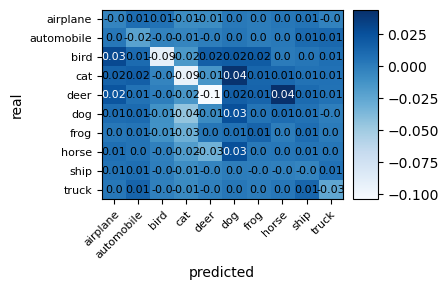

stage/mask_id: 5/4
Nonzero parameters:   114,872 --- 29.38%


100%|██████████| 79/79 [00:00<00:00, 243.60it/s]


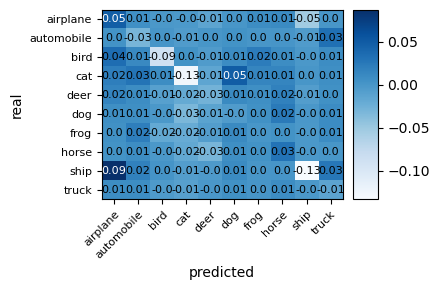

stage/mask_id: 6/5
Nonzero parameters:   118,029 --- 30.19%


100%|██████████| 79/79 [00:00<00:00, 242.33it/s]


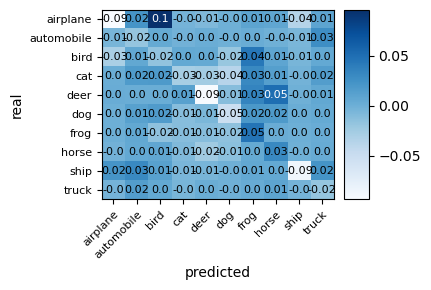

stage/mask_id: 7/6
Nonzero parameters:   101,809 --- 26.04%


100%|██████████| 79/79 [00:00<00:00, 254.23it/s]


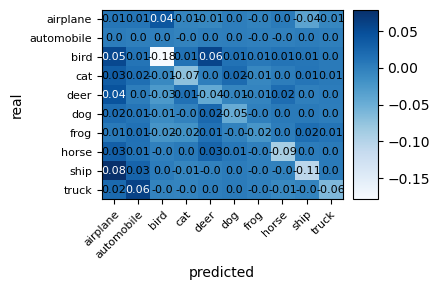

stage/mask_id: 8/7
Nonzero parameters:   110,558 --- 28.28%


100%|██████████| 79/79 [00:00<00:00, 243.67it/s]


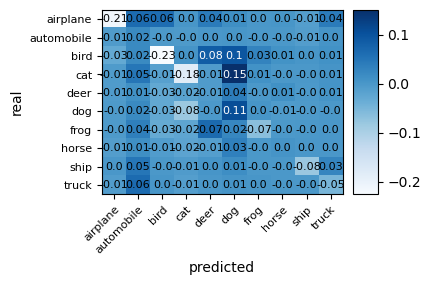

stage/mask_id: 9/8
Nonzero parameters:   94,108 --- 24.07%


100%|██████████| 79/79 [00:00<00:00, 253.44it/s]


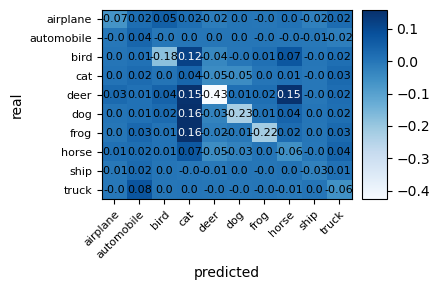

stage/mask_id: 10/9
Nonzero parameters:   100,455 --- 25.69%


100%|██████████| 79/79 [00:00<00:00, 246.62it/s]


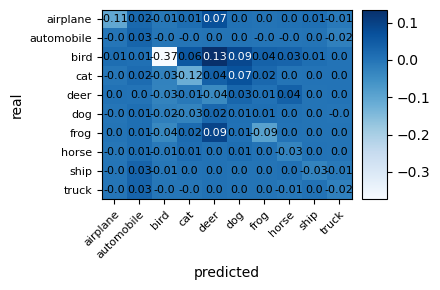

In [24]:
task.prepare_model_for_analysis()


for stage, mask_id in enumerate([-1]+task.mask_classes):
    split = "baseline" if stage==0 else task.train_set.class_names[mask_id]

    task.model.set_active(stage)

    # set = task.create_restricted_train_set([i for i in range(task.train_set.n_classes) if i != mask_id])
    # task.create_validate_on_train(set)

    print(f"stage/mask_id: {stage}/{mask_id}")

    model_1 = task.model.masks[stage]
    nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

    print(f"Nonzero parameters:   {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

    # If mask is finished training
    test, _ = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
    confusion = test.confusion.type(torch.float32)
    confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
    # Have a reference mask which is all the classes?
    if stage == 0:
        confusion_ref = confusion
        task.draw_confusion_heatmap(confusion_ref).to_matplotlib()
        plt.show()
    else:
        diff = confusion - confusion_ref
        task.draw_confusion_heatmap(diff).to_matplotlib()
        plt.show()

In [15]:
from pathlib import Path

rundir = "./save/cifar10/export/stage_final_masks/"

In [16]:
p = Path(Path.cwd() / rundir)
p

PosixPath('/home/Raffew/Projects/Csordas_modules/save/cifar10/export/stage_final_masks')

In [17]:
num_folders = len([1 for entry in Path(rundir).iterdir() if entry.is_dir()])
num_folders

11

In [18]:
for stage in range(num_folders):
    weights = [torch.load(w, weights_only=False).reshape(-1) for w in Path().glob(f"{rundir}/stage_{stage}/**/*.pth")]
    print(weights)
    break

[array([ 2.6369717 ,  4.2277794 ,  0.32757622,  3.3867707 ,  2.202412  ,
        2.7907357 ,  3.9601774 ,  3.8849027 , -0.87059575,  3.628717  ,
        4.8582044 ,  3.914536  ,  3.7285867 ,  4.91843   ,  0.96754944,
        3.8703272 ,  4.6419497 ,  2.9565852 ,  5.281751  ,  2.3181372 ,
       -0.9727629 ,  3.207938  ,  4.378098  ,  4.164818  ,  4.1138935 ,
        1.380721  ,  4.4770722 ,  0.7525988 ,  4.090915  ,  5.2594066 ,
        2.1235492 ,  3.7790024 ], dtype=float32), array([  2.7225559 ,   3.02551   ,   2.849883  ,   2.5457292 ,
       -14.275013  ,   2.276333  ,   3.0462253 ,   3.1276858 ,
         1.4251386 ,   2.1693234 ,   2.608265  ,   2.3473783 ,
         1.5338578 ,   2.5995681 ,   1.6134914 ,   3.4293299 ,
         3.0120208 ,   2.8966882 ,   2.6364508 ,   2.8086507 ,
         3.1172192 ,   2.316188  ,   2.3552263 ,   2.4949074 ,
         3.074001  ,   3.0390007 ,   2.8033593 ,   3.5945482 ,
         3.423007  ,   1.5939145 ,   1.5494925 ,   2.4914427 ,
         2.97

In [24]:
for x in task.model.masks[0].parameters():
    print(x)

Parameter containing:
tensor([ 2.6370,  4.2278,  0.3276,  3.3868,  2.2024,  2.7907,  3.9602,  3.8849,
        -0.8706,  3.6287,  4.8582,  3.9145,  3.7286,  4.9184,  0.9675,  3.8703,
         4.6419,  2.9566,  5.2818,  2.3181, -0.9728,  3.2079,  4.3781,  4.1648,
         4.1139,  1.3807,  4.4771,  0.7526,  4.0909,  5.2594,  2.1235,  3.7790],
       device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[[[  2.7226,   3.0255,   2.8499],
          [  2.5457, -14.2750,   2.2763],
          [  3.0462,   3.1277,   1.4251]],

         [[  2.1693,   2.6083,   2.3474],
          [  1.5339,   2.5996,   1.6135],
          [  3.4293,   3.0120,   2.8967]],

         [[  2.6365,   2.8087,   3.1172],
          [  2.3162,   2.3552,   2.4949],
          [  3.0740,   3.0390,   2.8034]]],


        [[[  3.5945,   3.4230,   1.5939],
          [  1.5495,   2.4914,   2.9793],
          [  2.3863,   2.9125,   1.7734]],

         [[  3.6370,   3.6746,   1.5607],
          [  1.9315,   3.3054,   2.

# NOTES

When looking at the 11 "masks", the first mask is a mask made to "keep" the output and last layer. Look into "def class_removal_init_masks_and_optim" to see the usage. 

Only dataloaders have a random seed "set", but that is still randomized.

They loos quite a lot of performance in their subnetworks, if i understand their confusion matrices correctly.

Masks are initialized as "2.0" --> All masks start out the same.

The normalize the data with these tensor values:

MEAN:

    array([[[125.3069 ]],

        [[122.95015]],

        [[113.866  ]]], dtype=float32)

STD:

    array([[[62.992565]],

       [[62.08881 ]],

       [[66.70408 ]]], dtype=float32)

They never change the underlying model parameter values, they only do some "masking magic"